In [6]:
!pip install ucimlrepo --quiet


Loaded dataset: 3000 samples, 11 columns


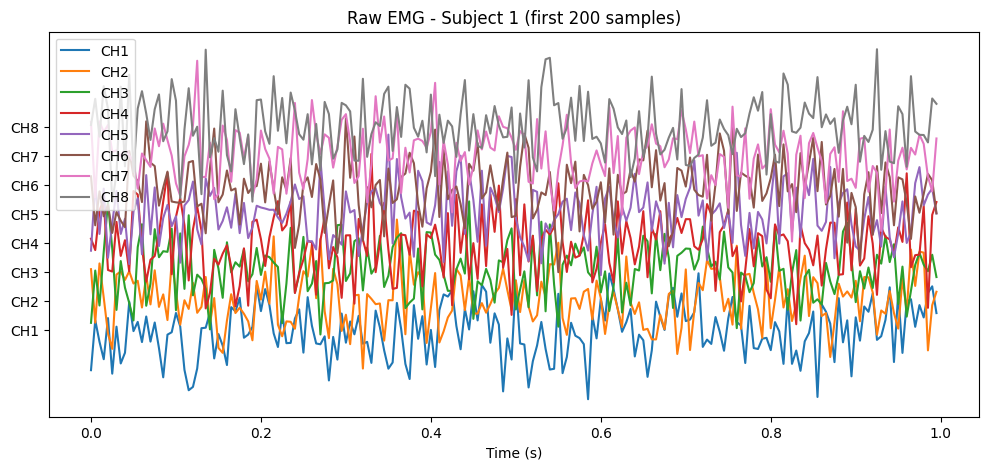

In [8]:
# =========================================
# EMG Analysis in Colab with Dummy Data
# =========================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

# -----------------------------------------
# Config
# -----------------------------------------
MANUAL_DATA_DIR = "/content/emg_data_for_gestures"
OUT_DIR = "/content/outputs"
FS = 200  # sampling rate
CHANNEL_NAMES = [f"CH{i}" for i in range(1, 9)]
GESTURE_LABELS = {
    0: "Unmarked", 1: "Rest", 2: "Fist", 3: "Wrist Flexion",
    4: "Wrist Extension", 5: "Radial Deviation",
    6: "Ulnar Deviation", 7: "Extended Palm"
}
MAX_SUBJECTS = 3

os.makedirs(MANUAL_DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------------------
# Create a dummy dataset if none exists
# -----------------------------------------
if not glob.glob(os.path.join(MANUAL_DATA_DIR, "*.txt")):
    print("No manual files found. Generating dummy data...")
    n_samples = 1000
    for subj in range(1, MAX_SUBJECTS+1):
        # time in ms
        time = np.arange(n_samples) * 5  # 200 Hz -> 5 ms per sample
        # random EMG signals
        signals = np.random.randn(n_samples, len(CHANNEL_NAMES)) * 0.5
        # random classes 0-7
        classes = np.random.choice(list(GESTURE_LABELS.keys()), n_samples)
        data = np.column_stack([time, signals, classes])
        file_path = os.path.join(MANUAL_DATA_DIR, f"subject{subj}.txt")
        np.savetxt(file_path, data, fmt="%.3f")
        print(f"Dummy data saved: {file_path}")

# -----------------------------------------
# Load manual files
# -----------------------------------------
def load_single_txt(filepath, subject_id):
    df = pd.read_csv(filepath, sep=r"\s+", header=None,
                     names=["time"] + CHANNEL_NAMES + ["class"], engine="python")
    df["subject_id"] = subject_id
    df["class"] = df["class"].astype(int)
    return df

def load_manual_files(data_dir, max_subjects=MAX_SUBJECTS):
    txt_files = sorted(glob.glob(os.path.join(data_dir, "*.txt")))
    txt_files = txt_files[:max_subjects]
    frames = []
    for i, fpath in enumerate(txt_files):
        df = load_single_txt(fpath, i+1)
        frames.append(df)
    df_all = pd.concat(frames, ignore_index=True)
    return df_all

df = load_manual_files(MANUAL_DATA_DIR)
print(f"Loaded dataset: {df.shape[0]} samples, {len(df.columns)} columns")

# -----------------------------------------
# Structure into NumPy arrays
# -----------------------------------------
signals, labels, times = {}, {}, {}
for subj_id, group in df.groupby("subject_id"):
    signals[subj_id] = group[CHANNEL_NAMES].values.astype(np.float32)
    labels[subj_id] = group["class"].values.astype(np.int32)
    times[subj_id] = group["time"].values / 1000.0

# -----------------------------------------
# Plot a dataset overview
# -----------------------------------------
s1 = list(signals.keys())[0]
sig1, t1 = signals[s1], times[s1]

plt.figure(figsize=(12,5))
offset = 0.5
for ch in range(8):
    plt.plot(t1[:200], sig1[:200,ch]+ch*offset, label=f"CH{ch+1}")
plt.yticks([ch*offset for ch in range(8)], [f"CH{ch+1}" for ch in range(8)])
plt.xlabel("Time (s)")
plt.title(f"Raw EMG - Subject {s1} (first 200 samples)")
plt.legend()
plt.show()


In [10]:
from IPython.display import Image, display

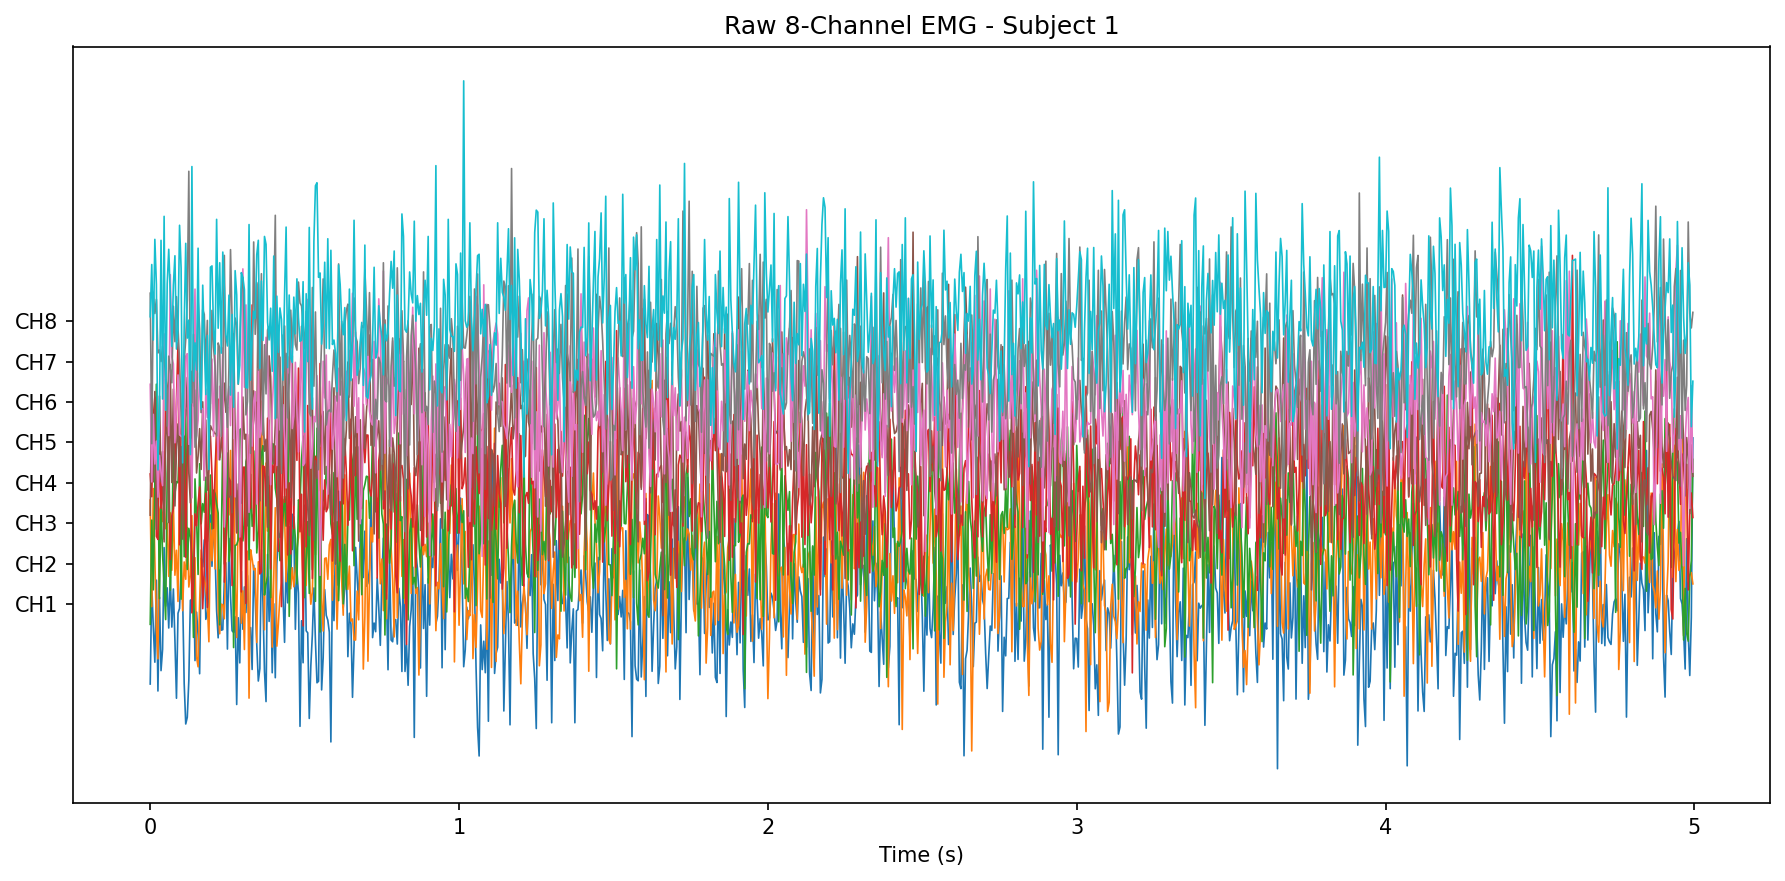

In [14]:
fig1 = plot_dataset_overview(df, signals, labels, times)

# Define the path to save
p1 = os.path.join(OUT_DIR, "dataset_overview.png")

# Save figure
fig1.savefig(p1, dpi=150, bbox_inches='tight')
plt.close(fig1)

# Display in Colab
from IPython.display import Image, display
display(Image(filename=p1))

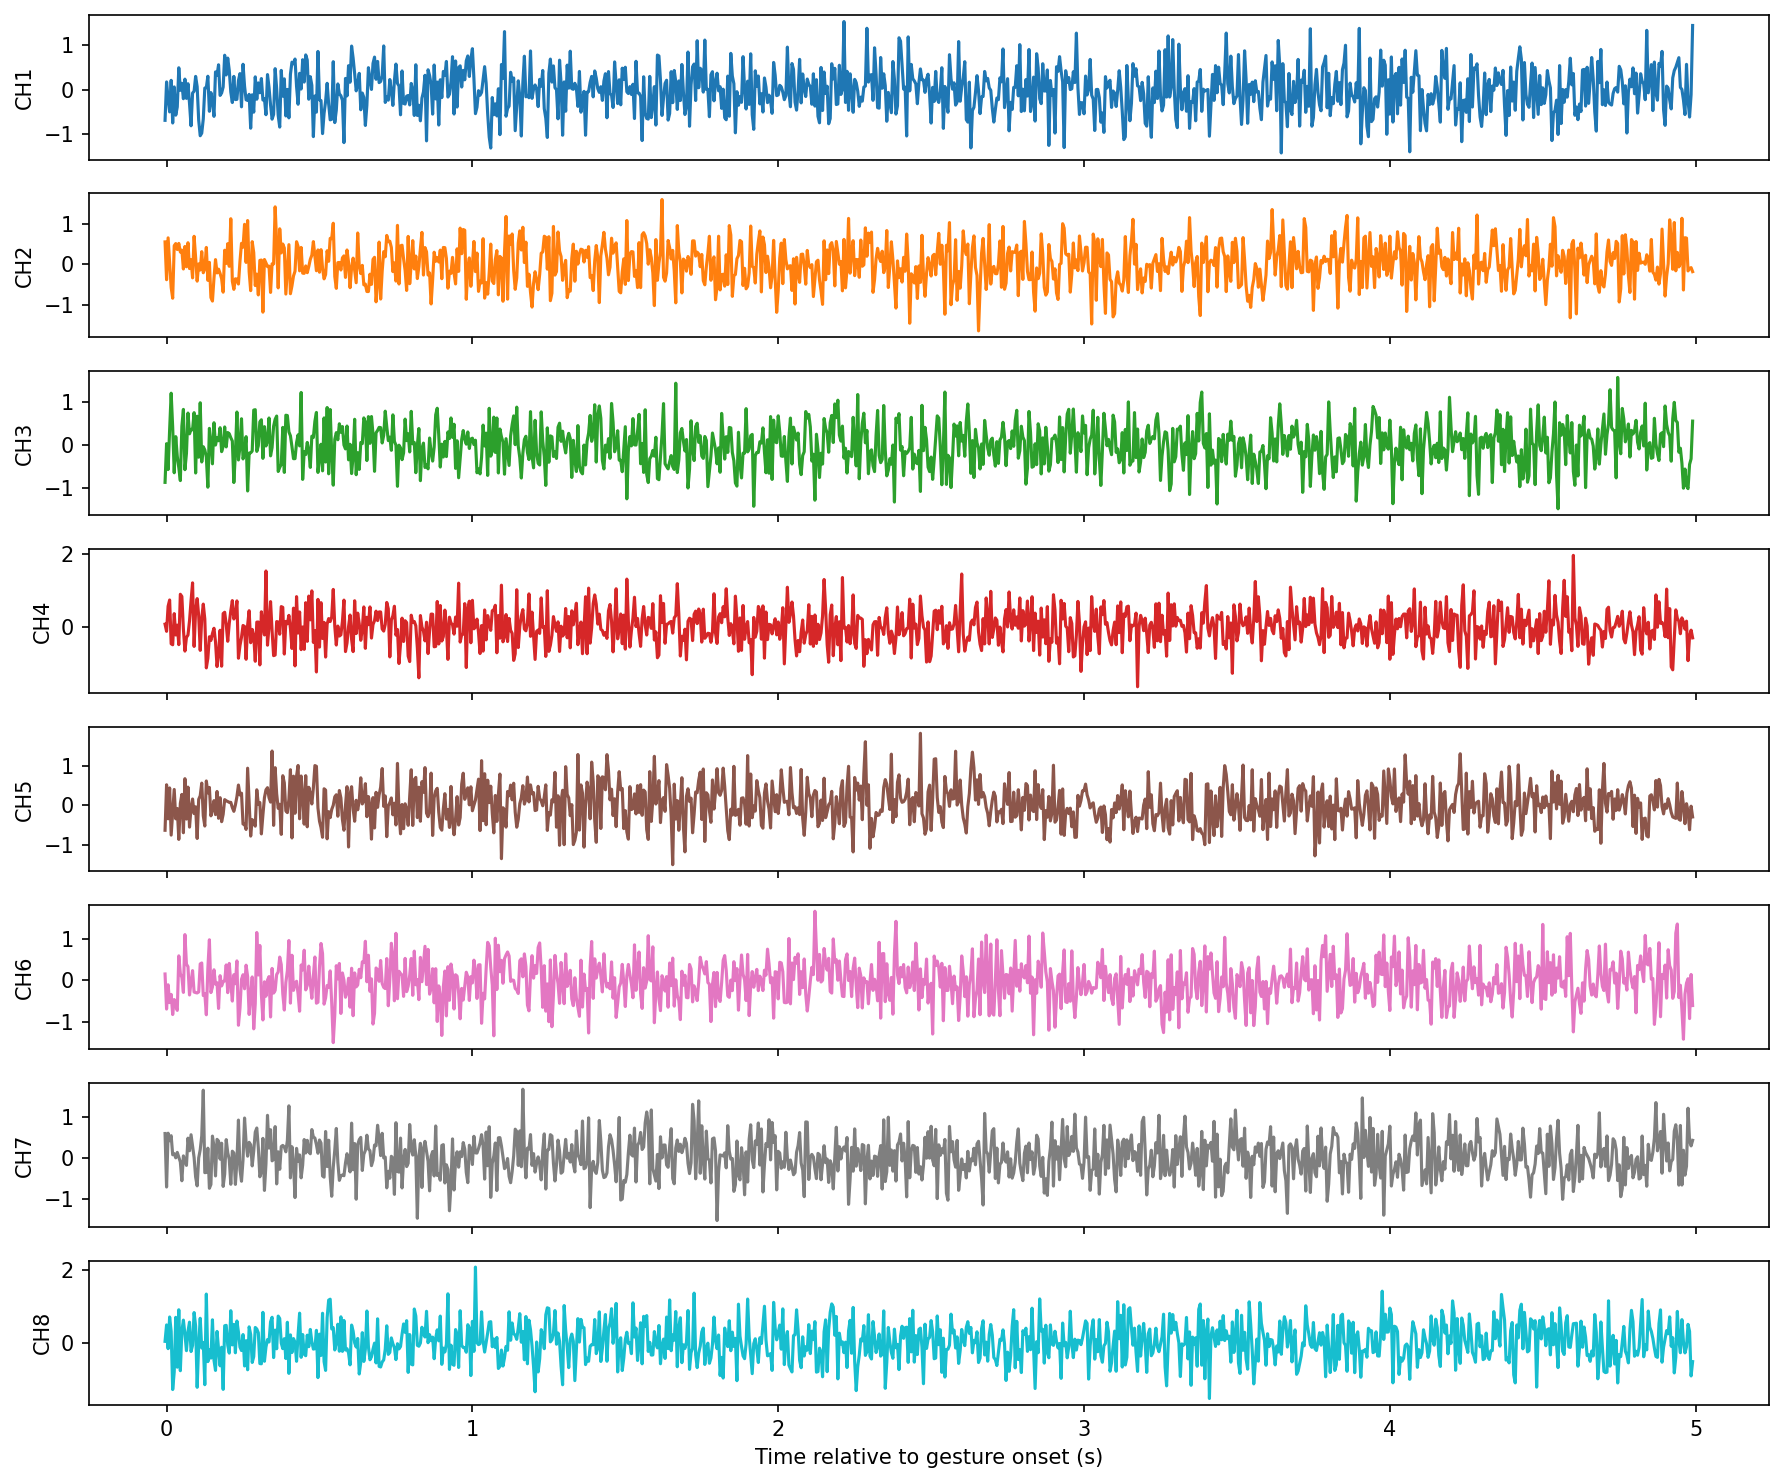

In [16]:
fig2 = plot_single_gesture_detail(signals, labels, times, gesture_id=2)
if fig2:
    p2 = os.path.join(OUT_DIR, "gesture_detail_fist.png")
    fig2.savefig(p2, dpi=150, bbox_inches='tight')
    plt.close(fig2)
    display(Image(filename=p2))